In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import astropy.constants as c
import astropy.units  as u

## you can undo the lines below (but it will be fun for making fancy plots!)
# to make the lines below work, you have to download the file 'PostProcessingScripts' from https://github.com/FloorBroekgaarden/common_code
# and put this in the same directory as this one, and then only use the bottom line from this code below 
import sys
sys.path.append('../../common_code') 
# from PostProcessingScripts import * 

# to make the screen wider
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


# import GROWL catalog info 
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/GROWL-catalog-public/growl_common_code') 
from growl_catalog import *
from common_functions import *


import h5py 

import pandas as pd
import numpy as np
import h5py


fc_list = ['channel II intrinsic (z=0) OSMT', 'channel V intrinsic (z=0) other without CE', 'channel I intrinsic (z=0) classic', 'channel III intrinsic (z=0) SCCE',\
'channel IV intrinsic (z=0) DCCE	channel', 'V intrinsic (z=0) other with CE', \
           'fraction with common envelope',  'fraction without common envelope']



formation_channel_dict = {'channel II intrinsic (z=0) OSMT':{'fc_values':[2]
                                                            },
                          'channel V intrinsic (z=0) other without CE':{'fc_values':[-2]
                                                            },
                          'channel I intrinsic (z=0) classic':{'fc_values':[1]
                                                            },
                          'channel III intrinsic (z=0) SCCE':{'fc_values':[3]
                                                            },
                          'channel IV intrinsic (z=0) DCCE	channel':{'fc_values':[4]
                                                            },
                          'V intrinsic (z=0) other with CE':{'fc_values':[-1]
                                                            },
                          'channel V intrinsic (z=0) CE not specified':{'fc_values':[]
                                                            },
                          'All intrinsic (z=0) [Gpc^-3 yr^-1]':{'fc_values':[-2, -1, 1, 2, 3, 4, 5]
                                                            },
                          'fraction without common envelope':{'fc_values':[2, -2]
                                                            },
                          'fraction with common envelope':{'fc_values':[1, 3, 4, -1]
                                                            }
}


In [67]:
import pandas as pd
import numpy as np
import h5py

def save_rate_fc_to_csv(boesky_dataset_list, growl_catalog, fc_list, formation_channel_dict, 
                        dataset="alpha0_1beta0_5", redshift_key="0.125", output_file="rate_fc.csv"):
    """
    Compute rate_fc values for each model in boesky_dataset_list and save to CSV.
    
    Parameters
    ----------
    boesky_dataset_list : list
        List of dataset identifiers (models).
    growl_catalog : str
        Path or catalog root used in get_folder_path_convolution_output.
    fc_list : list
        List of formation channel names (excluding the 'All intrinsic' total).
    formation_channel_dict : dict
        Dictionary mapping fc_name to fc_values.
    dataset : str
        Subfolder name of dataset (default "alpha0_1beta0_5").
    redshift_key : str
        Redshift key for convolution results (default "0.125").
    output_file : str
        Filename for output CSV.
    """
    results = []

    for data in boesky_dataset_list:
        print('Calculating formation channel contributions...')
        folder_path = get_folder_path_convolution_output(growl_catalog, "Boesky24", dataset=data)

        # --- read in bps data (formation channels) ---
        full_path_bps = folder_path + 'bps_output.h5'
        df_bps = pd.read_hdf(full_path_bps, key="input_data")
        formation_channel = df_bps["formation_channel"].to_numpy()

        # --- read in sspc data (yield) ---
        full_path_sspc = folder_path + 'sspc_output.h5'
        key_prefix = f"output_data/growl/intrinsic/convolution_results/{redshift_key}/"
        with h5py.File(full_path_sspc, "r") as f:
            yield_data = f[key_prefix + "yield"][()]

        # --- compute per-dataset results ---
        row = {"model": data}

        # total rate (independent of fc_list)
        row["All intrinsic (z=0) [Gpc^-3 yr^-1]"] = np.sum(yield_data)

        # per-formation-channel rates
        for fc_name in fc_list:
            fc_values_list = formation_channel_dict[fc_name]['fc_values']
            if len(fc_values_list) == 0:
                row[fc_name] = np.nan
            else:
                # calculate fractions
                mask_fc = np.in1d(formation_channel, np.asarray(fc_values_list))
                row[fc_name] = np.sum(yield_data[mask_fc])/np.sum(yield_data)
                
                
                if fc_name=='channel II intrinsic (z=0) OSMT':
                    print('OSMT : ', 'number = ', len(yield_data[mask_fc]), ' rate = ', yield_data[mask_fc])
                elif fc_name=='fraction without common envelope':
                    print('fraction without common envelope : ', 'number = ', len(yield_data[mask_fc]), ' rate = ', yield_data[mask_fc])
        results.append(row)

    # --- save to CSV ---
    df_results = pd.DataFrame(results)
    df_results.to_csv(output_file, index=False)
    print(f"Saved rate_fc results to {output_file}")
    return df_results


In [146]:

for dco_type in ['BBH', 'BHNS', 'BNS']:
    base_path = '/Volumes/GROWL/GROWL_bps_compact/%s/'%dco_type
    # Assuming you have the GROWL catalog from the previous artifact
    growl_catalog = build_growl_catalog(base_path=base_path)
    #print GROWL catalog possible entries
    print_catalog_summary(growl_catalog)

    boesky_dataset_list = list_datasets(growl_catalog, 'Boesky24')
    print(boesky_dataset_list)

    df_rates = save_rate_fc_to_csv(
        boesky_dataset_list,
        growl_catalog,
        fc_list,
        formation_channel_dict,
        dataset="alpha0_1beta0_5",
        redshift_key="0.125",
        output_file=  str(dco_type) + "_rate_fc.csv"
    )



GROWL Catalog Summary:

Author: Boesky24
  File: bps_output.h5
  Datasets (19):
    - alpha0_1beta0_25
    - alpha0_1beta0_5
    - alpha0_1beta0_75
    - alpha0_5beta0_25
    - alpha0_5beta0_5
    - alpha0_5beta0_75
    - alpha10_beta0_25
    - alpha10_beta0_5
    - alpha10_beta0_75
    - alpha2_beta0_5
    - alpha2beta0_25
    - sigma_265_RMP_Mandel
    - sigma_265_RMP_Rapid
    - sigma_30_RMP_Delayed
    - sigma_30_RMP_Mandel
    - sigma_30_RMP_Rapid
    - sigma_750_RMP_Delayed
    - sigma_750_RMP_Mandel
    - sigma_750_RMP_Rapid
['alpha0_1beta0_25', 'alpha0_1beta0_5', 'alpha0_1beta0_75', 'alpha0_5beta0_25', 'alpha0_5beta0_5', 'alpha0_5beta0_75', 'alpha10_beta0_25', 'alpha10_beta0_5', 'alpha10_beta0_75', 'alpha2_beta0_5', 'alpha2beta0_25', 'sigma_265_RMP_Mandel', 'sigma_265_RMP_Rapid', 'sigma_30_RMP_Delayed', 'sigma_30_RMP_Mandel', 'sigma_30_RMP_Rapid', 'sigma_750_RMP_Delayed', 'sigma_750_RMP_Mandel', 'sigma_750_RMP_Rapid']
Calculating formation channel contributions...
OSMT :  numbe

OSMT :  number =  15652  rate =  [1.33754202e-05 1.01594653e-07 1.58308235e-06 ... 5.26681078e-07
 1.09854404e-10 5.61320406e-07]
fraction without common envelope :  number =  15652  rate =  [1.33754202e-05 1.01594653e-07 1.58308235e-06 ... 5.26681078e-07
 1.09854404e-10 5.61320406e-07]
Saved rate_fc results to BBH_rate_fc.csv
GROWL Catalog Summary:

Author: Boesky24
  File: bps_output.h5
  Datasets (19):
    - alpha0_1beta0_25
    - alpha0_1beta0_5
    - alpha0_1beta0_75
    - alpha0_5beta0_25
    - alpha0_5beta0_5
    - alpha0_5beta0_75
    - alpha10_beta0_25
    - alpha10_beta0_5
    - alpha10_beta0_75
    - alpha2_beta0_5
    - alpha2beta0_25
    - sigma_265_RMP_Mandel
    - sigma_265_RMP_Rapid
    - sigma_30_RMP_Delayed
    - sigma_30_RMP_Mandel
    - sigma_30_RMP_Rapid
    - sigma_750_RMP_Delayed
    - sigma_750_RMP_Mandel
    - sigma_750_RMP_Rapid
['alpha0_1beta0_25', 'alpha0_1beta0_5', 'alpha0_1beta0_75', 'alpha0_5beta0_25', 'alpha0_5beta0_5', 'alpha0_5beta0_75', 'alpha10_beta0

OSMT :  number =  139  rate =  [1.79804281e-04 6.87826324e-04 4.49448895e-05 2.31799699e-07
 8.84924969e-04 1.03445088e-04 1.31748794e-04 7.59272083e-05
 4.35975824e-04 1.25100778e-04 6.85862183e-06 2.89965721e-04
 4.57118870e-04 2.03413757e-04 6.59251990e-05 0.00000000e+00
 4.24273929e-04 2.66624298e-05 7.39834133e-06 6.28048304e-05
 2.90544145e-07 1.27267434e-06 5.16775670e-05 1.24385554e-07
 0.00000000e+00 7.19145088e-07 8.89203944e-08 1.05872079e-06
 4.74767549e-06 8.74704839e-10 4.58902300e-06 2.77716716e-07
 1.03090693e-06 5.35958180e-07 5.04490418e-05 5.25080085e-07
 1.33961193e-06 9.37754273e-07 1.06885308e-06 9.33990686e-08
 1.46642747e-07 2.24612023e-05 1.92384322e-05 1.59147071e-06
 3.27444847e-07 2.77466522e-06 3.47115662e-07 1.00680012e-06
 1.83581805e-06 2.30822428e-07 8.04077150e-06 6.32827469e-08
 4.04154228e-05 6.97279956e-08 3.70293321e-07 1.31405808e-04
 2.15574775e-05 8.29815489e-08 1.10448598e-07 5.94736115e-07
 1.79425757e-09 1.03676060e-06 4.28987868e-07 2.459775

OSMT :  number =  5  rate =  [1.94573443e-04 1.15616068e-04 5.81166957e-07 4.99940345e-07
 1.01343725e-06]
fraction without common envelope :  number =  5  rate =  [1.94573443e-04 1.15616068e-04 5.81166957e-07 4.99940345e-07
 1.01343725e-06]
Calculating formation channel contributions...
OSMT :  number =  5  rate =  [2.04486236e-04 2.46687591e-04 1.66279268e-04 1.61177745e-09
 2.89649891e-09]
fraction without common envelope :  number =  5  rate =  [2.04486236e-04 2.46687591e-04 1.66279268e-04 1.61177745e-09
 2.89649891e-09]
Calculating formation channel contributions...
OSMT :  number =  12  rate =  [2.81543600e-04 3.89722076e-07 1.19874813e-05 1.36258942e-07
 4.59781078e-07 2.74213427e-06 1.14718371e-08 2.31458568e-08
 1.13654869e-07 6.00024983e-09 3.94715404e-08 2.92577993e-07]
fraction without common envelope :  number =  12  rate =  [2.81543600e-04 3.89722076e-07 1.19874813e-05 1.36258942e-07
 4.59781078e-07 2.74213427e-06 1.14718371e-08 2.31458568e-08
 1.13654869e-07 6.00024983e-

OSMT :  number =  563  rate =  [2.70839505e-04 5.93979398e-05 6.35047311e-06 4.44399459e-06
 8.31376876e-06 1.41977995e-04 3.77755510e-04 3.87864509e-04
 5.18490403e-04 5.64658058e-04 2.46361530e-04 3.77755510e-04
 9.87096726e-04 3.17421276e-05 4.62235808e-04 2.86638446e-04
 1.69911676e-04 3.87806947e-04 5.43835008e-07 1.30176224e-08
 2.89470244e-07 5.18490403e-04 1.02493810e-03 2.93499438e-04
 1.32187819e-04 4.08492403e-04 5.76283233e-04 1.19712225e-08
 3.11131464e-04 8.34634820e-04 5.99557384e-04 1.01306163e-04
 4.84484459e-04 2.84925686e-04 2.43534551e-06 4.29637650e-04
 2.67801971e-03 2.89470252e-07 8.53564889e-09 2.51717604e-08
 5.99557384e-04 8.97675057e-04 3.48292434e-04 2.60183904e-04
 4.12169361e-07 4.08492403e-04 4.08492403e-04 2.08192098e-04
 3.77755510e-04 2.60183904e-04 1.37141005e-04 1.91792728e-03
 5.43834386e-07 1.22698815e-04 5.99557384e-04 1.78231063e-06
 4.32824482e-04 3.87864509e-04 6.57304427e-04 3.95128858e-06
 2.68267327e-04 7.96907260e-05 2.93499438e-04 3.763515

OSMT :  number =  2  rate =  [0.00115165 0.00130618]
fraction without common envelope :  number =  2  rate =  [0.00115165 0.00130618]
Calculating formation channel contributions...
OSMT :  number =  3  rate =  [0.00071301 0.00132112 0.00087724]
fraction without common envelope :  number =  3  rate =  [0.00071301 0.00132112 0.00087724]
Calculating formation channel contributions...
OSMT :  number =  2  rate =  [0.00072982 0.00055628]
fraction without common envelope :  number =  2  rate =  [0.00072982 0.00055628]
Calculating formation channel contributions...
OSMT :  number =  5  rate =  [0.00027363 0.00023854 0.00026143 0.00027363 0.00027464]
fraction without common envelope :  number =  5  rate =  [0.00027363 0.00023854 0.00026143 0.00027363 0.00027464]
Calculating formation channel contributions...
OSMT :  number =  2  rate =  [0.0008741 0.0007916]
fraction without common envelope :  number =  2  rate =  [0.0008741 0.0007916]
Saved rate_fc results to BNS_rate_fc.csv


### Some tests to figure out why the formation channel rate of SMT channel changes for fixed beta

Answer: it must be sampling uncertainty (for some simulations the total SMT BBHs is so low that it misses an island of them (with low ZAMS masses...))

In [56]:
# dco_type='BBH'
# base_path = '/Volumes/GROWL/GROWL_bps_compact/%s/'%dco_type
# # Assuming you have the GROWL catalog from the previous artifact
# growl_catalog = build_growl_catalog(base_path=base_path)
# #print GROWL catalog possible entries
# print_catalog_summary(growl_catalog)

# boesky_dataset_list = list_datasets(growl_catalog, 'Boesky24')
# print(boesky_dataset_list)

# df_rates = save_rate_fc_to_csv(
#     boesky_dataset_list,
#     growl_catalog,
#     fc_list,
#     formation_channel_dict,
#     dataset="alpha0_1beta0_5",
#     redshift_key="0.125",
#     output_file=  str(dco_type) + "_rate_fc.csv"
# )



In [57]:
! ls

BBH_rate_fc.csv
Calculate_and_Save_Formation_Channels_Boesky24_data.ipynb


In [ ]:
## Older code, in case I want to go back 

In [ ]:





for data in boesky_dataset_list:
    print(data)
    folder_path = get_folder_path_convolution_output(growl_catalog, "Boesky24", dataset="alpha0_1beta0_5")
    
    ###### read in bps data   ######
    full_path_bps = folder_path + 'bps_output.h5'
    df = pd.read_hdf(full_path_bps, key="input_data")
    # bps parameters to get
    formation_channel = df["formation_channel"]
    
    ###### read in sspc data   ######
    full_path_sspc = folder_path + 'sspc_output.h5'
    redshift_key="0.125"
    key = f"output_data/growl/intrinsic/convolution_results/{redshift_key}/"
#     df = pd.read_hdf(full_path_bps, key=key)


    with h5py.File(full_path_sspc, "r") as f:
        key = f"output_data/growl/intrinsic/convolution_results/{redshift_key}/"
        yield_data = f[key + "yield"][()]
#         unit_dict = extract_unit_dict(f, key)  # optional


    
    
    
    for ind_fc, fc_name in enumerate(fc_list):
        fc_values_list = formation_channel_dict[fc_name]['fc_values']
        print(fc_values_list)
        mask_fc = np.in1d(formation_channel, np.asarray(fc_values_list))
        rate_fc = np.sum(yield_data[mask_fc])
        print(fc_name, '  =  ',  rate_fc)
        
    
    

    
    
    
  
    

In [ ]:

# def save_rate_fc_to_csv(boesky_dataset_list, growl_catalog, fc_list, formation_channel_dict, 
#                         dataset="alpha0_1beta0_5", redshift_key="0.125", output_file="rate_fc.csv"):
#     """
#     Compute rate_fc values for each model in boesky_dataset_list and save to CSV.
    
#     Parameters
#     ----------
#     boesky_dataset_list : list
#         List of dataset identifiers (models).
#     growl_catalog : str
#         Path or catalog root used in get_folder_path_convolution_output.
#     fc_list : list
#         List of formation channel names.
#     formation_channel_dict : dict
#         Dictionary mapping fc_name to fc_values.
#     dataset : str
#         Subfolder name of dataset (default "alpha0_1beta0_5").
#     redshift_key : str
#         Redshift key for convolution results (default "0.125").
#     output_file : str
#         Filename for output CSV.
#     """
#     results = []

#     for data in boesky_dataset_list:
#         folder_path = get_folder_path_convolution_output(growl_catalog, "Boesky24", dataset=data)

#         # --- read in bps data (formation channels) ---
#         full_path_bps = folder_path + 'bps_output.h5'
#         df_bps = pd.read_hdf(full_path_bps, key="input_data")
#         formation_channel = df_bps["formation_channel"].to_numpy()

#         # --- read in sspc data (yield) ---
#         full_path_sspc = folder_path + 'sspc_output.h5'
#         key_prefix = f"output_data/growl/intrinsic/convolution_results/{redshift_key}/"
#         with h5py.File(full_path_sspc, "r") as f:
#             yield_data = f[key_prefix + "yield"][()]
        
#         total_rate = np.sum(yield_data)
#         'All intrinsic (z=0) [Gpc^-3 yr^-1]'

#         # --- compute rates per formation channel ---
#         row = {"model": data}
        
#         for fc_name in fc_list:
#             fc_values_list = formation_channel_dict[fc_name]['fc_values']
#             if len(fc_values_list) == 0:  # skip empty lists
#                 row[fc_name] = np.nan
#             else:
#                 mask_fc = np.in1d(formation_channel, np.asarray(fc_values_list))
#                 row[fc_name] = np.sum(yield_data[mask_fc])/total_rate
#         results.append(row)
#         print(row)

#     # --- save to CSV ---
#     df_results = pd.DataFrame(results)
#     df_results.to_csv(output_file, index=False)
#     print(f"Saved rate_fc results to {output_file}")
#     return df_results





In [83]:
print(boesky_dataset_list)

['alpha0_1beta0_25', 'alpha0_1beta0_5', 'alpha0_1beta0_75', 'alpha0_5beta0_25', 'alpha0_5beta0_5', 'alpha0_5beta0_75', 'alpha10_beta0_25', 'alpha10_beta0_5', 'alpha10_beta0_75', 'alpha2_beta0_5', 'alpha2beta0_25', 'sigma_265_RMP_Mandel', 'sigma_265_RMP_Rapid', 'sigma_30_RMP_Delayed', 'sigma_30_RMP_Mandel', 'sigma_30_RMP_Rapid', 'sigma_750_RMP_Delayed', 'sigma_750_RMP_Mandel', 'sigma_750_RMP_Rapid']


In [97]:

# import GROWL catalog info 
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/GROWL-catalog-public/growl_common_code') 
from growl_catalog import *
from common_functions import *



import sys
sys.path.append('/Users/floorbroekgaarden/Projects/GitHub/GROWL-catalog-public/formation_channels')
from formation_channels_Boesky import * 



In [93]:

base_path = '/Volumes/GROWL/GROWL_bps/'
# Assuming you have the GROWL catalog from the previous artifact
growl_catalog = build_growl_catalog(base_path=base_path)
#print GROWL catalog possible entries
print_catalog_summary(growl_catalog)

boesky_dataset_list = list_datasets(growl_catalog, 'Boesky24')
# print(boesky_dataset_list)




for data_name in boesky_dataset_list[:]:
    folder_path = get_folder_path_convolution_output(growl_catalog, "Boesky24", dataset=data_name)
    full_path = folder_path + 'COMPAS_Output_Weighted.h5'
    print(full_path)
    fdata = h5.File(full_path, 'r')
    
    print(fdata['BSE_System_Parameters']["SEED"][()][0:10])
#     print(fdata['BSE_System_Parameters'].keys())
    print('CE alpha sys= ', fdata['BSE_System_Parameters']['CE_Alpha'][()][0])
    print('MT fa sys= ', fdata['BSE_System_Parameters']['MT_Fraction_Accreted'][()][0])

    alpha_CE = fdata['Run_Details']['common-envelope-alpha'][()]
    print('alpha =', alpha_CE)

#     alpha_CE = fdata['Run_Details']['common-envelope-alpha-Derivation'][()]
#     print('alpha =',alpha_CE)

    mt_fa= fdata['Run_Details']['mass-transfer-fa'][()]
    print('beta =', mt_fa)
#     mt_fa= fdata['Run_Details']['mass-transfer-fa-Derivation'][()]
#     print('betaaa =', mt_fa)
    print('\n \n \n')



    fdata.close()

GROWL Catalog Summary:

Author: Boesky24
  File: COMPAS_Output_Weighted.h5
  Datasets (19):
    - alpha0_1beta0_25
    - alpha0_1beta0_5
    - alpha0_1beta0_75
    - alpha0_5beta0_25
    - alpha0_5beta0_5
    - alpha0_5beta0_75
    - alpha10_beta0_25
    - alpha10_beta0_5
    - alpha10_beta0_75
    - alpha2_beta0_5
    - alpha2beta0_25
    - sigma_265_RMP_Mandel
    - sigma_265_RMP_Rapid
    - sigma_30_RMP_Delayed
    - sigma_30_RMP_Mandel
    - sigma_30_RMP_Rapid
    - sigma_750_RMP_Delayed
    - sigma_750_RMP_Mandel
    - sigma_750_RMP_Rapid
/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_25/COMPAS_Output_Weighted.h5
[0 1 2 3 4 5 6 7 8 9]
CE alpha sys=  0.1
MT fa sys=  0.25
alpha = [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1
 0.1 0.1]
beta = [0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25 0.25
 0.25 0.25 0.25 0.25 0.25 0.25]

 
 

/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_5/COMPAS_Output_Weighted.h5
[0 1 2 3 4 5 6 7 8 9]
CE alpha s

OSError: [Errno 6] Can't read data (file read failed: time = Thu Aug 28 17:07:47 2025
, filename = '/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_5beta0_5/COMPAS_Output_Weighted.h5', file descriptor = 75, errno = 6, error message = 'Device not configured', buf = 0x3b288c000, total read size = 160000000, bytes this sub-read = 160000000, bytes actually read = 18446744073709551615, offset = 0)

alpha0_1beta0_25
/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_25/COMPAS_Output_Weighted.h5
<KeysViewHDF5 ['BSE_Common_Envelopes', 'BSE_Double_Compact_Objects', 'BSE_RLOF', 'BSE_Supernovae', 'BSE_System_Parameters', 'Run_Details']>


In [147]:

full_path = '/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_25/COMPAS_Output_Weighted.h5'
print(full_path)
fdata = h5.File(full_path, 'r')

# print(fdata.keys())
# print(fdata['BSE_System_Parameters'].keys())


# print(fdata['BSE_System_Parameters']["SEED"][()][0:10])
# #     print(fdata['BSE_System_Parameters'].keys())
# print('CE alpha sys= ', fdata['BSE_System_Parameters']['CE_Alpha'][()][0])
# print('MT fa sys= ', fdata['BSE_System_Parameters']['MT_Fraction_Accreted'][()][0])

# alpha_CE = fdata['Run_Details']['common-envelope-alpha'][()]
# print('alpha =', alpha_CE)

# #     alpha_CE = fdata['Run_Details']['common-envelope-alpha-Derivation'][()]
# #     print('alpha =',alpha_CE)

# mt_fa= fdata['Run_Details']['mass-transfer-fa'][()]
# print('beta =', mt_fa)
# #     mt_fa= fdata['Run_Details']['mass-transfer-fa-Derivation'][()]
# #     print('betaaa =', mt_fa)
# print('\n \n \n')



SEED_DCO = fdata['BSE_Double_Compact_Objects']["SEED"][()]

SEED_sys = fdata['BSE_System_Parameters']["SEED"][()]




# formation_channels = identify_formation_channels(SEED_DCO, fdata)

# mask_SMT = (formation_channels==2)

# print('no SMT =', np.sum(mask_SMT), ' out of n binaries = ', len(fdata['BSE_System_Parameters']["SEED"][()]))



for seed in SEED_sys[:10]:
    mask_seed_sys = fdata['BSE_System_Parameters']["SEED"][()] ==seed
    
    print('sys ', seed, fdata['BSE_System_Parameters']['Metallicity'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(2)'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(1)'][()][mask_seed_sys])

    mask_seed_dco = fdata['BSE_Double_Compact_Objects']["SEED"][()] ==seed
    print('DCO ', seed, fdata['BSE_Double_Compact_Objects']['Mass(1)'][()][mask_seed_dco], fdata['BSE_Double_Compact_Objects']['Mass(2)'][()][mask_seed_dco])
    print()

#     for key in ['Initial_Mass_Function', 'Semi-Major_Axis_Dstrbtn', 'Initial_Mass_Func_Max', 'Initial_Mass_Func_Min', 'Initial_Mass_Func_Power', 'Metallicity_Dstrbtn', 'Metallicity_Dstrbtn_Max', 'Metallicity_Dstrbtn_Min']:
#         print(key, fdata['BSE_System_Parameters'][key][()][mask_seed_sys])





# formation_channels = identify_formation_channels(SEED_DCO, fdata)

# mask_SMT = (formation_channels==2)

# print('no SMT =', np.sum(mask_SMT), ' out of n binaries = ', len(fdata['BSE_System_Parameters']["SEED"][()]))

# # for seed in SEED_DCO[:10]:
# for seed in [14, 32, 94, 97, 183, 219, 228, 412, 430, 484 ]:
#     mask_seed_sys = fdata['BSE_System_Parameters']["SEED"][()] ==seed
    
#     print('sys ', seed, fdata['BSE_System_Parameters']['Metallicity'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(2)'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(1)'][()][mask_seed_sys])

#     mask_seed_dco = fdata['BSE_Double_Compact_Objects']["SEED"][()] ==seed
#     print('DCO ', seed, fdata['BSE_Double_Compact_Objects']['Mass(1)'][()][mask_seed_dco], fdata['BSE_Double_Compact_Objects']['Mass(2)'][()][mask_seed_dco])
#     print()
#     for key in ['Initial_Mass_Function', 'Semi-Major_Axis_Dstrbtn', 'Initial_Mass_Func_Max', 'Initial_Mass_Func_Min', 'Initial_Mass_Func_Power', 'Metallicity_Dstrbtn', 'Metallicity_Dstrbtn_Max', 'Metallicity_Dstrbtn_Min']:
#         print(key, fdata['BSE_System_Parameters'][key][()][mask_seed_sys])

fdata.close()

/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_25/COMPAS_Output_Weighted.h5


FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_25/COMPAS_Output_Weighted.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [118]:
for ind_d, full_path in enumerate(['/Volumes/GROWL/GROWL_bps/Boesky24/alpha10_beta0_25/COMPAS_Output_Weighted.h5', '/Volumes/GROWL/GROWL_bps/Boesky24/alpha10_beta0_25/COMPAS_Output_Weighted.h5'])


fdata = h5.File(full_path, 'r')

# print(fdata.keys())
# print(fdata['BSE_System_Parameters'].keys())


# print(fdata['BSE_System_Parameters']["SEED"][()][0:10])
# #     print(fdata['BSE_System_Parameters'].keys())
# print('CE alpha sys= ', fdata['BSE_System_Parameters']['CE_Alpha'][()][0])
# print('MT fa sys= ', fdata['BSE_System_Parameters']['MT_Fraction_Accreted'][()][0])

# alpha_CE = fdata['Run_Details']['common-envelope-alpha'][()]
# print('alpha =', alpha_CE)

# #     alpha_CE = fdata['Run_Details']['common-envelope-alpha-Derivation'][()]
# #     print('alpha =',alpha_CE)

# mt_fa= fdata['Run_Details']['mass-transfer-fa'][()]
# print('beta =', mt_fa)
#     mt_fa= fdata['Run_Details']['mass-transfer-fa-Derivation'][()]
#     print('betaaa =', mt_fa)
print('\n \n \n')



SEED_DCO = fdata['BSE_Double_Compact_Objects']["SEED"][()]
SEED_sys = fdata['BSE_System_Parameters']["SEED"][()]




formation_channels = identify_formation_channels(SEED_DCO, fdata)

mask_SMT = (formation_channels==2)

print('no SMT =', np.sum(mask_SMT), ' out of n binaries = ', len(fdata['BSE_System_Parameters']["SEED"][()]))



for seed in SEED_sys[:10]:
    mask_seed_sys = fdata['BSE_System_Parameters']["SEED"][()] ==seed
    
    print('sys ', seed, fdata['BSE_System_Parameters']['Metallicity'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(2)'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(1)'][()][mask_seed_sys])

    mask_seed_dco = fdata['BSE_Double_Compact_Objects']["SEED"][()] ==seed
    print('DCO ', seed, fdata['BSE_Double_Compact_Objects']['Mass(1)'][()][mask_seed_dco], fdata['BSE_Double_Compact_Objects']['Mass(2)'][()][mask_seed_dco])
    print()

#     for key in ['Initial_Mass_Function', 'Semi-Major_Axis_Dstrbtn', 'Initial_Mass_Func_Max', 'Initial_Mass_Func_Min', 'Initial_Mass_Func_Power', 'Metallicity_Dstrbtn', 'Metallicity_Dstrbtn_Max', 'Metallicity_Dstrbtn_Min']:
#         print(key, fdata['BSE_System_Parameters'][key][()][mask_seed_sys])





# for seed in SEED_DCO[:10]:
#     mask_seed_sys = fdata['BSE_System_Parameters']["SEED"][()] ==seed
    
#     print('sys ', seed, fdata['BSE_System_Parameters']['Metallicity'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(2)'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(1)'][()][mask_seed_sys])

#     mask_seed_dco = fdata['BSE_Double_Compact_Objects']["SEED"][()] ==seed
#     print('DCO ', seed, fdata['BSE_Double_Compact_Objects']['Mass(1)'][()][mask_seed_dco], fdata['BSE_Double_Compact_Objects']['Mass(2)'][()][mask_seed_dco])
#     print()

#     for key in ['Initial_Mass_Function', 'Semi-Major_Axis_Dstrbtn', 'Initial_Mass_Func_Max', 'Initial_Mass_Func_Min', 'Initial_Mass_Func_Power', 'Metallicity_Dstrbtn', 'Metallicity_Dstrbtn_Max', 'Metallicity_Dstrbtn_Min']:
#         print(key, fdata['BSE_System_Parameters'][key][()][mask_seed_sys])

fdata.close()

/Volumes/GROWL/GROWL_bps/Boesky24/alpha10_beta0_25/COMPAS_Output_Weighted.h5

 
 

sys  0 [0.0010334] [20.31574708] [91.41829247]
DCO  0 [] []

sys  1 [0.00056126] [4.73793727] [6.23361489]
DCO  1 [] []

sys  2 [0.00054393] [2.09091898] [7.61916976]
DCO  2 [] []

sys  3 [0.00024672] [7.59907192] [8.40397443]
DCO  3 [] []

sys  4 [0.00753438] [4.06686098] [5.11816333]
DCO  4 [] []

sys  5 [0.02767686] [10.48755882] [42.88971885]
DCO  5 [] []

sys  6 [0.0015376] [0.49420022] [5.83929015]
DCO  6 [] []

sys  7 [0.00032955] [20.37377864] [23.68157682]
DCO  7 [] []

sys  8 [0.00043919] [2.21056856] [6.36590997]
DCO  8 [] []

sys  9 [0.00064035] [0.32828851] [5.04551554]
DCO  9 [] []



/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_25/COMPAS_Output_Weighted.h5
total w sys =  20027175.019776624
total w dco =  250576.03557664144
sum SMT =  48276.16987345489

/Volumes/GROWL/GROWL_bps/Boesky24/alpha10_beta0_25/COMPAS_Output_Weighted.h5
total w sys =  20022101.818419028
total w dco =  374792.47877330316
sum SMT =  59866.34059460011



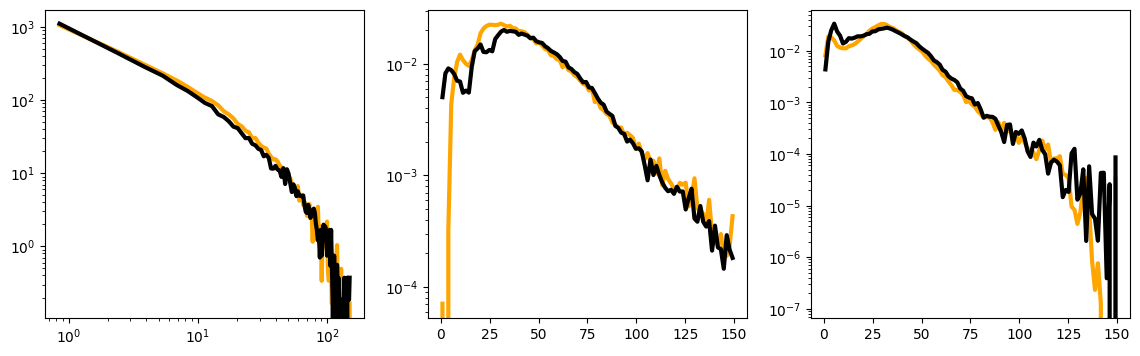

In [144]:

# for key in ['Metallicity', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)']:
    
#     fig, ax = plt.subplots(figsize=(10,10))
fig, axes = plt.subplots(figsize=(14,4), nrows=1, ncols=3)
for ind_d, full_path in enumerate(['/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_75/COMPAS_Output_Weighted.h5', '/Volumes/GROWL/GROWL_bps/Boesky24/alpha10_beta0_75/COMPAS_Output_Weighted.h5']):
    print(full_path)
    if ind_d ==0:
        color = 'orange'
    elif ind_d==1:
        color='black'

    fdata = h5.File(full_path, 'r')
    xvar = fdata['BSE_System_Parameters'][key][()]
    w = fdata['BSE_System_Parameters']['mixture_weight'][()]

    SEED_DCO = fdata['BSE_Double_Compact_Objects']["SEED"][()]
    SEED_sys = fdata['BSE_System_Parameters']["SEED"][()]


    formation_channels = identify_formation_channels(SEED_DCO, fdata)
    mask_SMT = (formation_channels==2)



    mask_sys_from_dco = np.in1d(SEED_sys, SEED_DCO)
    w_dco = w[mask_sys_from_dco]
    print('total w sys = ', np.sum(w))
    print('total w dco = ', np.sum(w_dco))

    print('sum SMT = ', np.sum(w_dco[mask_SMT]))
    
    print()
    
    mask_sys_from_SMTdco = np.in1d(SEED_sys, SEED_DCO[mask_SMT])
#     print(fdata['BSE_Double_Compact_Objects'].keys())
#     w_from_dco = fdata['BSE_Double_Compact_Objects']['mixture_weight'][()][mask_SMT]
    
    
    for ind_k, key in enumerate(['Metallicity', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)']):
        
        ax = axes[ind_k]
        xvar = fdata['BSE_System_Parameters'][key][()][mask_sys_from_SMTdco]
        
        
        
        hist, bin_edges = np.histogram(
                xvar, 
                bins=100, 
                density=True,
            weights=w[mask_sys_from_SMTdco]
            )        

        ax.plot(bin_centers, hist, lw=3, label=ind_d, color=color)        
        
        
#         hist, bin_edges = np.histogram(
#                 xvar, 
#                 bins=100, 
#                 density=True,
#             weights=w_from_dco
#             )          
#         ax.plot(bin_centers, hist, lw=6, label=ind_d, color=color, ls='-.', alpha=0.5, zorder=10)        
        
        ax.set_yscale('log')
        if key=='Metallicity':
            ax.set_xscale('log')
            
            
    fdata.close()
plt.show()
        
#         hist, bin_edges = np.histogram(
#                 xvar, 
#                 bins=100, 
#                 density=True,
#             weights=w
#             )
        
#         bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# #         ax.plot(bin_centers, hist, lw=3, label=ind_d, color=color)        
#     ax.set_yscale('log')
#     if key=='Metallicity':
#         ax.set_xscale('log')
#     plt.show()

In [ ]:
total w dco =  250576.03557664144
sum SMT =  48276.16987345489

0
1


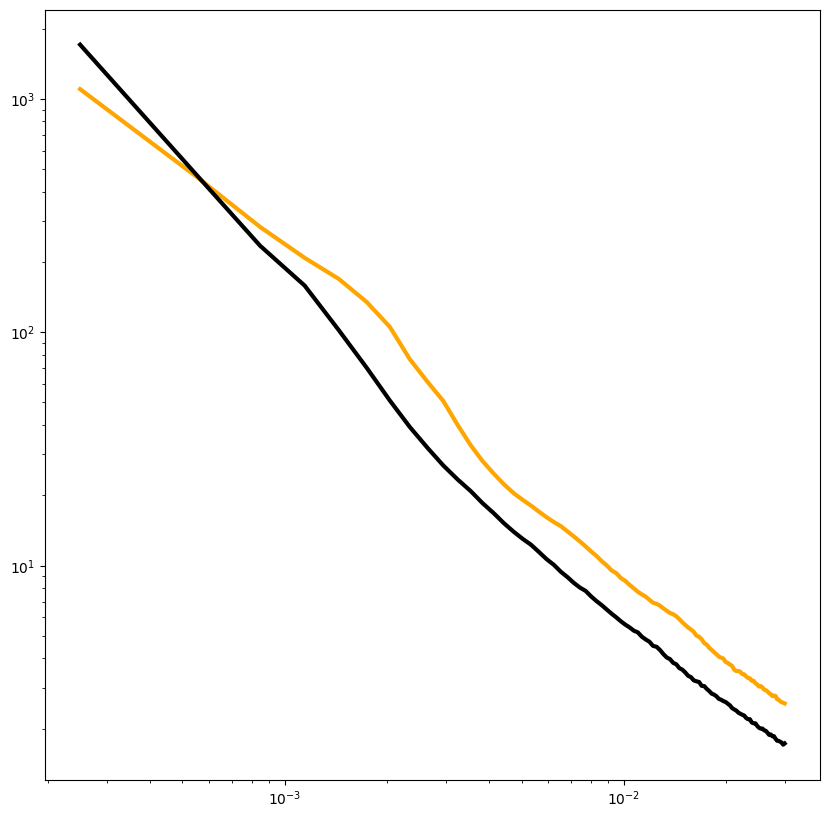

0
1


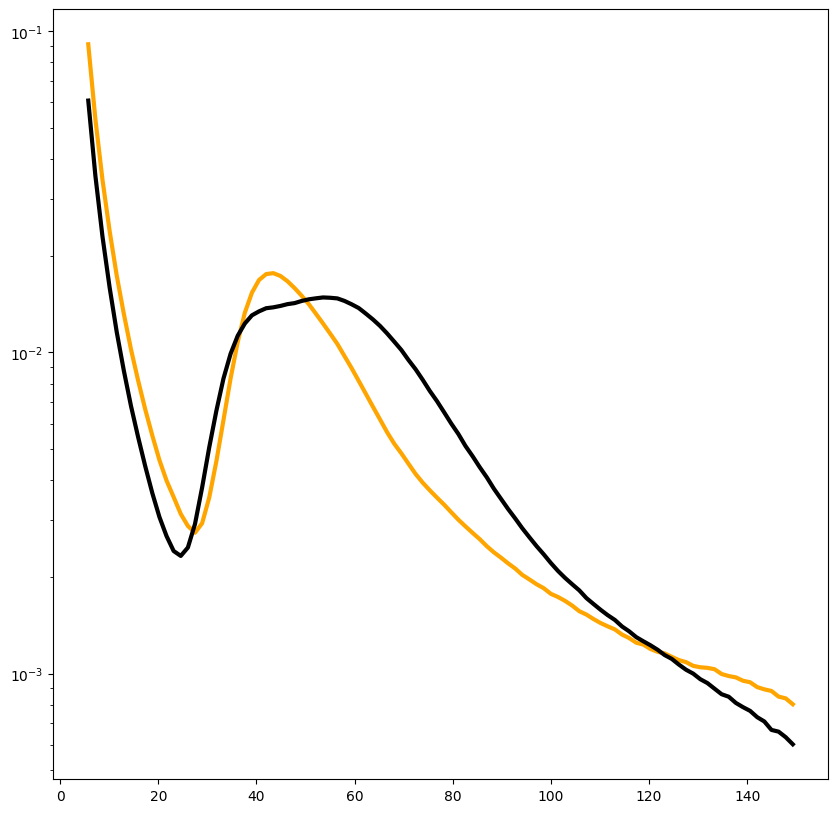

0
1


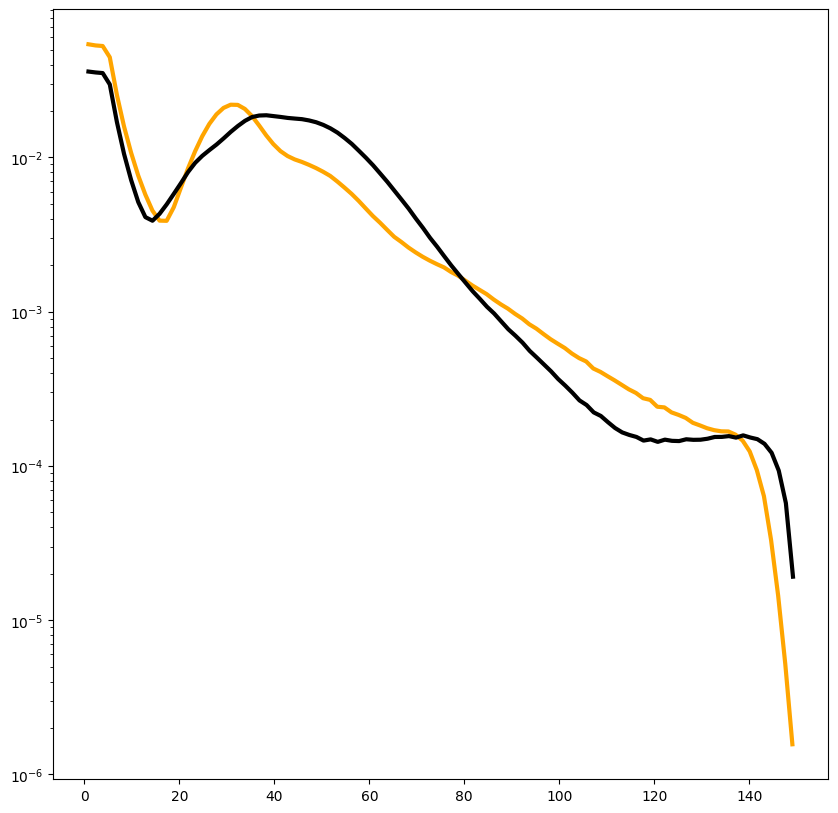

In [143]:

for key in ['Metallicity', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)']:
    
    fig, ax = plt.subplots(figsize=(10,10))
    for ind_d, full_path in enumerate(['/Volumes/GROWL/GROWL_bps/Boesky24/alpha0_1beta0_25/COMPAS_Output_Weighted.h5', '/Volumes/GROWL/GROWL_bps/Boesky24/alpha10_beta0_25/COMPAS_Output_Weighted.h5']):
        print(ind_d)
        if ind_d ==0:
            color = 'orange'
        elif ind_d==1:
            color='black'
        
        fdata = h5.File(full_path, 'r')
        xvar = fdata['BSE_System_Parameters'][key][()]
        w = fdata['BSE_System_Parameters']['mixture_weight'][()]
        
        
        
        hist, bin_edges = np.histogram(
                xvar, 
                bins=100, 
                density=True#,
#             weights=w
            )
        
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        ax.plot(bin_centers, hist, lw=3, label=ind_d, color=color)        
    ax.set_yscale('log')
    if key=='Metallicity':
        ax.set_xscale('log')
    plt.show()

In [107]:
! ls /Volumes/GROWL/GROWL_bps/Boesky24/

alpha0_1beta0_25      alpha10_beta0_5       sigma_30_RMP_Mandel
alpha0_1beta0_5       alpha10_beta0_75      sigma_30_RMP_Rapid
alpha0_1beta0_75      alpha2_beta0_5        sigma_750_RMP_Delayed
alpha0_5beta0_25      alpha2beta0_25        sigma_750_RMP_Mandel
alpha0_5beta0_5       sigma_265_RMP_Mandel  sigma_750_RMP_Rapid
alpha0_5beta0_75      sigma_265_RMP_Rapid
alpha10_beta0_25      sigma_30_RMP_Delayed


In [104]:
print(np.sum(mask_SMT))

for seed in SEED_DCO[:10]:
    mask_seed_sys = fdata['BSE_System_Parameters']["SEED"][()] ==seed
    
    print('sys ', seed, fdata['BSE_System_Parameters']['Metallicity'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(2)'][()][mask_seed_sys], fdata['BSE_System_Parameters']['Mass@ZAMS(1)'][()][mask_seed_sys])

    mask_seed_dco = fdata['BSE_Double_Compact_Objects']["SEED"][()] ==seed
    print('DCO ', seed, fdata['BSE_Double_Compact_Objects']['Mass(1)'][()][mask_seed_dco], fdata['BSE_Double_Compact_Objects']['Mass(2)'][()][mask_seed_dco])
    print()



2169914
79 [0.00103274] [33.13336666] [36.7496825]
79 [9.09675521] [10.85464309]
88 [0.00461252] [35.52213968] [38.35839432]
88 [15.45112413] [14.25695511]
95 [0.00010184] [43.13112719] [62.912184]
95 [26.37439122] [17.16354744]
399 [0.00062157] [6.04448405] [6.79419624]
399 [1.26] [1.27758353]
450 [0.00087634] [34.28254367] [44.40175953]
450 [14.94344841] [12.83446448]
485 [0.00107385] [37.60460426] [54.46638411]
485 [19.79445479] [14.54643998]
492 [0.00062708] [31.51878045] [47.39598235]
492 [17.78438235] [8.85953402]
643 [0.00566613] [58.03971906] [70.90455113]
643 [18.73297745] [15.32402829]
688 [0.00010255] [51.17581495] [51.2058197]
688 [20.86104636] [20.83493057]
848 [0.02566398] [6.42470822] [11.15407007]
848 [1.26000503] [1.27755573]


In [113]:
full_path = '/Volumes/GROWL/GROWL_bps/Boesky24/alpha10_beta0_25/COMPAS_Output_Weighted.h5'
print(full_path)
fdata = h5.File(full_path, 'r')

/Volumes/GROWL/GROWL_bps/Boesky24/alpha10_beta0_25/COMPAS_Output_Weighted.h5


In [115]:
print(fdata['BSE_Double_Compact_Objects'].keys())

print(fdata['BSE_System_Parameters'].keys())

fdata.close()

<KeysViewHDF5 ['Coalescence_Time', 'Eccentricity@DCO', 'Mass(1)', 'Mass(2)', 'Merges_Hubble_Time', 'Recycled_NS(1)', 'Recycled_NS(2)', 'SEED', 'SemiMajorAxis@DCO', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Time', 'mixture_weight']>
<KeysViewHDF5 ['Add_Options_To_SysParms', 'Allow_Immediate_RLOF>CE_To_Survive_CE', 'Allow_MS_To_Survive_CE', 'Allow_Non_Stripped_ECSN', 'Allow_RLOF@Birth', 'Allow_Radiative_Envelope_To_Survive_CE', 'Allow_Touching@Birth', 'BB_Mass_xFer_Stblty_Prscrptn', 'BH_Kicks', 'CE_Alpha', 'CE_Alpha_Thermal', 'CE_Lambda', 'CE_Lambda_Multiplier', 'CE_Lambda_Prscrptn', 'CE_Mass_Accr_Constant', 'CE_Mass_Accr_Max', 'CE_Mass_Accr_Min', 'CE_Mass_Accr_Prscrptn', 'CE_Recomb_Enrgy_Dnsty', 'CE_Slope_Kruckow', 'CHE_Mode', 'CH_on_MS(1)', 'CH_on_MS(2)', 'Check_Photon_Tiring_Limit', 'Circularise@MT', 'Conserve_AngMom@Circ', 'Cool_WindMassLoss_Multipl', 'Eccentricity', 'Eccentricity@ZAMS', 'Eccentricity_Dstrbtn', 'Eccentricity_Dstrbtn_Max', 'Eccentricity_Dstrbtn_Min', 'Eddington_Accr_Fact

In [ ]:
    base_path = '/Volumes/GROWL/GROWL_bps_compact/%s/'%dco_type
    # Assuming you have the GROWL catalog from the previous artifact
    growl_catalog = build_growl_catalog(base_path=base_path)
    #print GROWL catalog possible entries
    print_catalog_summary(growl_catalog)